Anomali Tespit Aracı
Model yükleniyor: C:\Users\PC\Desktop\21subat\25_subat\just_lstm_autoencoder.h5
Model başarıyla yüklendi.
Test verisi başarıyla yüklendi. 120 paket bulundu.
(120, 12)
Index(['hour', 'minute', 'second', 'size', 'source_port', 'destination_port',
       'ttl', 'protocol_TCP', 'protocol_UDP', 'SYN', 'ACK', 'FIN'],
      dtype='object')
   hour  minute  second  size  source_port  destination_port    ttl  \
0     8      14      17    60        58390               443    254   
1     8      14      17    70          443             58390  16386   
2     8      14      16    60        58761             28194  65535   
3     8      14      17    65        59212               443    254   
4     8      14      18    68          443             59212  16386   

   protocol_TCP  protocol_UDP  SYN  ACK  FIN  
0          True         False    0    1    0  
1          True         False    0    1    0  
2         False          True    1    0    0  
3          True         False

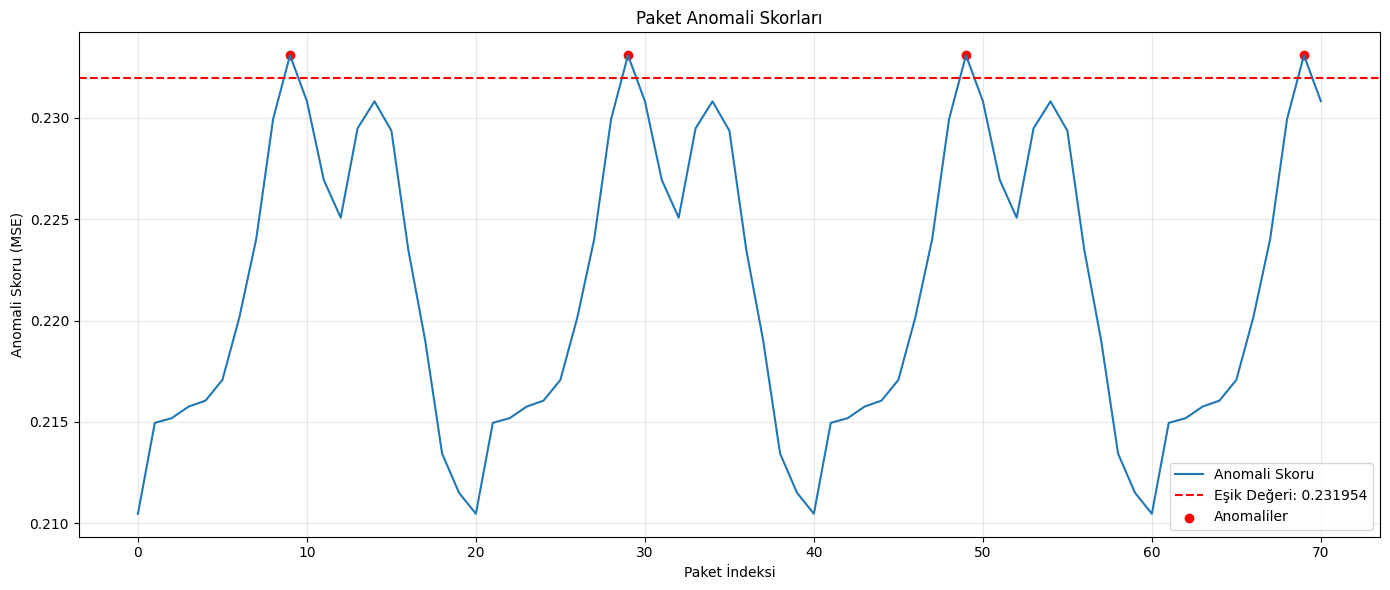

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import os
from tensorflow.keras.losses import mse as keras_mse
from sklearn.metrics import mean_squared_error as sklearn_mse, mean_absolute_error
from tensorflow.keras.models import load_model
import ipdb



def load_test_data(json_file_path):
    """
    Test verilerini JSON dosyasından yükler.
    
    Args:
        json_file_path (str): Test JSON dosyasının yolu
        
    Returns:
        pandas.DataFrame: Test verisi
    """
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
            
        # JSON verisini pandas DataFrame'e dönüştür
        df = pd.DataFrame(data['packets'])
        print(f"Test verisi başarıyla yüklendi. {len(df)} paket bulundu.")
        return df
    except Exception as e:
        print(f"Test verisi yüklenirken hata oluştu: {str(e)}")
        return None

def preprocess_data(df):
    """
    Test verisini modele uygun şekilde ön işler.
    
    Args:
        df (pandas.DataFrame): Ham test verisi
        
    Returns:
        pandas.DataFrame: İşlenmiş test verisi
    """
    
    try:
        # İlgili sütunları seç
        required_columns = ["hour", "minute", "second", "size", "source_port", "destination_port", "ttl", "protocol", "tcp_flags"]
        available_columns = [col for col in required_columns if col in df.columns]
        
        if not set(["hour", "minute", "second", "size"]).issubset(set(available_columns)):
            print("Uyarı: Bazı gerekli sütunlar eksik.")
        
        # Mevcut sütunları kullan
        df_processed = df[available_columns].copy()
        
        # Protokolleri one-hot encode et
        if "protocol" in df_processed.columns:
            df_processed = pd.get_dummies(df_processed, columns=["protocol"], prefix="protocol")
        
        # TCP bayraklarını işle
        if "tcp_flags" in df_processed.columns:
            df_processed["tcp_flags"] = df_processed["tcp_flags"].astype(str)
            df_processed["SYN"] = df_processed["tcp_flags"].apply(lambda x: int("SYN=true" in x))
            df_processed["ACK"] = df_processed["tcp_flags"].apply(lambda x: int("ACK=true" in x))
            df_processed["FIN"] = df_processed["tcp_flags"].apply(lambda x: int("FIN=true" in x))
            df_processed.drop(columns=["tcp_flags"], inplace=True)
        
        # TTL sütununu doldur
        if "ttl" in df_processed.columns and df_processed["ttl"].isna().any():
            df_processed["ttl"].fillna(df_processed["ttl"].median(), inplace=True)
        
        # NaN değerlerini doldur
        for col in df_processed.columns:
            if df_processed[col].dtype != 'object' and df_processed[col].isna().any():
                print(f"Uyarı: {col} sütununda NaN değerler var. Medyan ile dolduruluyor.")
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
        print(df_processed.shape)
        print(df_processed.columns)
        print(df_processed.head())
        return df_processed
    except Exception as e:
        print(f"Veri ön işleme sırasında hata oluştu: {str(e)}")
        return None

def detect_anomalies(model_path, test_data_path, sequence_length=50, threshold=None):
    """
    Test verisindeki anomalileri tespit eder.
    
    Args:
        model_path (str): Eğitilmiş model dosyasının yolu
        test_data_path (str): Test veri dosyasının yolu
        sequence_length (int): Dizilerin uzunluğu
        threshold (float): Anomali eşik değeri (None ise otomatik hesaplanır)
        
    Returns:
        list: Anomali indeksleri ve skoru
    """
    try:
        # 1. Modeli yükle
        print(f"Model yükleniyor: {model_path}")
        custom_objects = {'mse': keras_mse}

# LSTM Autoencoder modelini yükle
        model = load_model(model_path, 
							  custom_objects=custom_objects)

        print("Model başarıyla yüklendi.")
        
        # 2. Test verisini yükle ve ön işle
        raw_df = load_test_data(test_data_path)
        if raw_df is None:
            return None
            
        df = preprocess_data(raw_df)
        print("preprocess_data fonksiyonu başarıyla çalıştı.")
        if df is None:
            return None
            
        # 3. Veriyi normalize et
        scaler = MinMaxScaler()
        df_scaled = scaler.fit_transform(df)
        
        
        # 4. Rekonstrüksiyon hatalarını hesapla
        # 4.1 Tek tek paketler için anomali skorunu hesapla
        individual_scores = []
        for i in range(len(df_scaled)):
            # İndeks dışına çıkma durumunu kontrol et
            if i + sequence_length > len(df_scaled):
                break
                
            # Diziyi oluştur
            sequence = df_scaled[i:i+sequence_length]
            sequence = np.expand_dims(sequence, axis=0)  # Batch boyutunu ekle
            
            
            # Yeniden oluştur
            reconstructed = model.predict(sequence, verbose=0)
            
            # MSE hesapla
            mse = np.mean(np.power(sequence - reconstructed, 2))
            individual_scores.append((i, mse))
            

       
        
        
        # 5. Eşik değeri belirle
        if threshold is None:
            mse_values = [score for _, score in individual_scores]
            threshold = np.percentile(mse_values, 95)  # 95. yüzdelik
            print(f"Otomatik belirlenen anomali eşik değeri: {threshold:.6f}")
        else:
            print(f"Belirtilen anomali eşik değeri: {threshold:.6f}")
            
        # 6. Anomalileri belirle
        anomalies = []
        for idx, score in individual_scores:
            if score > threshold:
                anomalies.append((idx, score))
                
        # 7. Anomalileri raporla
        print(f"\nToplam {len(anomalies)} anomali tespit edildi.")
        print(f"Test verisinde {len(raw_df)} paket, {len(individual_scores)} sıralı dizi var.")
        
        if anomalies:
            print("\n--- Tespit Edilen Anomaliler ---")
            for idx, score in anomalies:
                print(f"Paket indeksi: {idx}, Anomali skoru: {score:.6f}")
                
                # İlgili paketin özelliklerini göster
                packet = raw_df.iloc[idx]
                print(f"Zaman: {packet['hour']:02d}:{packet['minute']:02d}:{packet['second']:02d}")
                print(f"Paket boyutu: {packet['size']} bayt")
                if 'protocol' in packet:
                    print(f"Protokol: {packet['protocol']}")
                if 'source_ip' in packet and 'destination_ip' in packet:
                    print(f"Kaynak IP: {packet['source_ip']}, Hedef IP: {packet['destination_ip']}")
                if 'source_port' in packet and 'destination_port' in packet:
                    print(f"Kaynak port: {packet['source_port']}, Hedef port: {packet['destination_port']}")
                if 'tcp_flags' in packet:
                    print(f"TCP bayrakları: {packet['tcp_flags']}")
                print("------------------------")
            
            # 8. Görselleştirme
            plt.figure(figsize=(14, 6))
            
            # Anomali skorları
            scores = [score for _, score in individual_scores]
            plt.plot(scores, label='Anomali Skoru')
            
            # Eşik değeri
            plt.axhline(y=threshold, color='r', linestyle='--', label=f'Eşik Değeri: {threshold:.6f}')
            
            # Anomalileri işaretle
            anomaly_indices = [idx for idx, _ in anomalies]
            anomaly_scores = [score for _, score in anomalies]
            plt.scatter(anomaly_indices, anomaly_scores, color='red', marker='o', label='Anomaliler')
            
            plt.title('Paket Anomali Skorları')
            plt.xlabel('Paket İndeksi')
            plt.ylabel('Anomali Skoru (MSE)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig("anomali_skorlari.png")
            print("Anomali skorları grafiği 'anomali_skorlari.png' dosyasına kaydedildi.")
            
        return anomalies
            
    except Exception as e:
        print(f"Anomali tespiti sırasında bir hata oluştu: {str(e)}")
        return None

def main():
    """
    Ana fonksiyon
    """
    print("Anomali Tespit Aracı")
    print("====================")
    
    # Model dosyasını seç
    model_path = 'C:\\Users\\PC\\Desktop\\21subat\\25_subat\\just_lstm_autoencoder.h5'
    if not os.path.exists(model_path):
        print(f"Hata: {model_path} dosyası bulunamadı.")
        return
    
    # Test verisini seç
    test_data_path ="C:\\Users\\PC\\Desktop\\21subat\\7mart\\test_verisi.json"
    if not os.path.exists(test_data_path):
        print(f"Hata: {test_data_path} dosyası bulunamadı.")
        return
    
    # Anomali tespitini gerçekleştir
    detect_anomalies(model_path, test_data_path)
    
    print("\nAnomaliler başarıyla tespit edildi!")

if __name__ == "__main__":
    main()

Anomali Tespit Aracı
Model yükleniyor: C:\Users\PC\Desktop\21subat\25_subat\just_lstm_autoencoder.h5
Model başarıyla yüklendi.
Model beklenen özellik sayısı: 12
Test verisi başarıyla yüklendi. 120 paket bulundu.
Preprocessed data shape: (120, 12)
Columns: ['hour', 'minute', 'second', 'size', 'source_port', 'destination_port', 'ttl', 'SYN', 'ACK', 'FIN', 'protocol_TCP', 'protocol_UDP']
preprocess_data fonksiyonu başarıyla çalıştı.
Ön işlenmiş veri özellikleri: 12
Otomatik belirlenen anomali eşik değeri: 0.255651

Toplam 4 anomali tespit edildi.
Test verisinde 120 paket, 71 sıralı dizi var.

--- Tespit Edilen Anomaliler ---
Paket indeksi: 9, Anomali skoru: 0.256357
Zaman: 08:14:22
Paket boyutu: 65 bayt
Protokol: UDP
Kaynak IP: 192.168.1.25, Hedef IP: 8.8.8.8
Kaynak port: 52136, Hedef port: 53
TCP bayrakları: SYN=false ACK=false FIN=false
------------------------
Paket indeksi: 29, Anomali skoru: 0.256357
Zaman: 08:14:22
Paket boyutu: 65 bayt
Protokol: UDP
Kaynak IP: 192.168.1.25, Hedef I

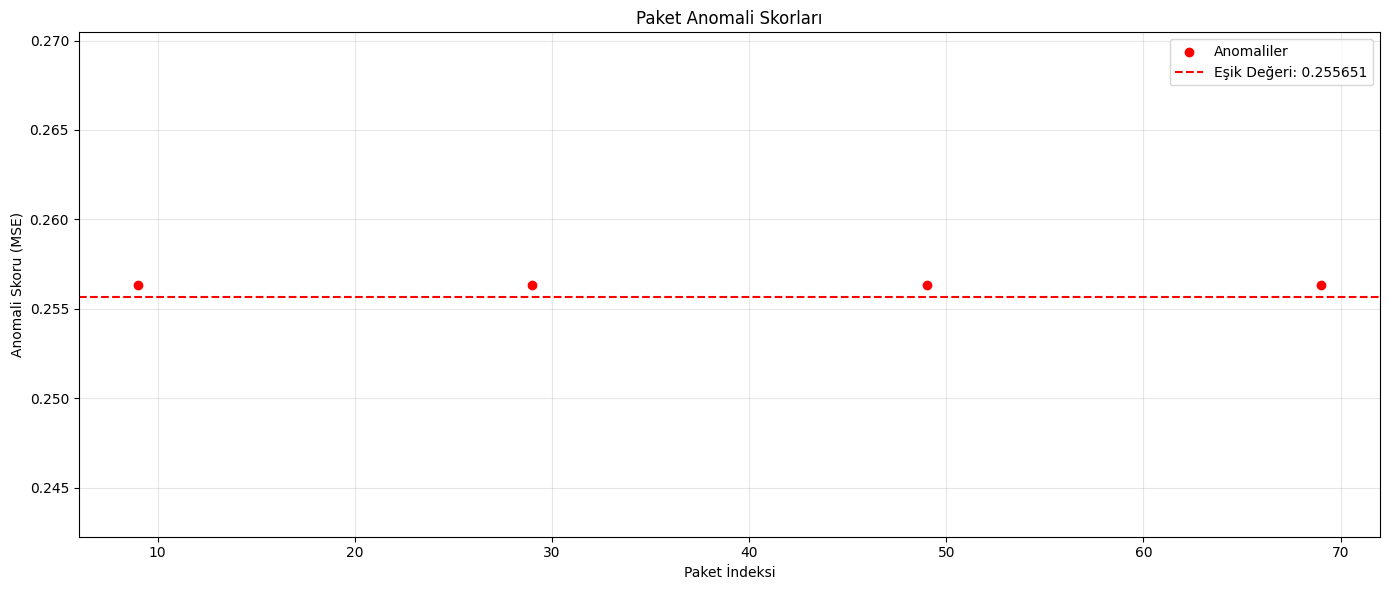

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import os
from tensorflow.keras.losses import mse as keras_mse
from tensorflow.keras.models import load_model

def load_test_data(json_file_path):
    """
    Test verilerini JSON dosyasından yükler.
    
    Args:
        json_file_path (str): Test JSON dosyasının yolu
        
    Returns:
        pandas.DataFrame: Test verisi
    """
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
            
        # JSON verisini pandas DataFrame'e dönüştür
        df = pd.DataFrame(data['packets'])
        print(f"Test verisi başarıyla yüklendi. {len(df)} paket bulundu.")
        return df
    except Exception as e:
        print(f"Test verisi yüklenirken hata oluştu: {str(e)}")
        return None

def preprocess_data(df, expected_columns=None):
    """
    Test verisini modele uygun şekilde ön işler.
    
    Args:
        df (pandas.DataFrame): Ham test verisi
        expected_columns (list): Model tarafından beklenen sütunlar (one-hot encoded dahil)
        
    Returns:
        pandas.DataFrame: İşlenmiş test verisi
    """
    
    try:
        # İlgili sütunları seç
        required_columns = ["hour", "minute", "second", "size", "source_port", "destination_port", "ttl", "protocol", "tcp_flags"]
        available_columns = [col for col in required_columns if col in df.columns]
        
        if not set(["hour", "minute", "second", "size"]).issubset(set(available_columns)):
            print("Uyarı: Bazı gerekli sütunlar eksik.")
        
        # Mevcut sütunları kullan
        df_processed = df[available_columns].copy()
        
        # Protokolleri one-hot encode et
        protocols_in_training = ["protocol_TCP", "protocol_UDP", "protocol_ICMP"]  # Eğitim verisindeki protokoller
        if "protocol" in df_processed.columns:
            protocol_df = pd.get_dummies(df_processed["protocol"], prefix="protocol")
            # Eğitim sırasında kullanılan tüm protokol sütunlarını ekle
            for protocol in protocols_in_training:
                if protocol not in protocol_df.columns:
                    protocol_df[protocol] = 0
            
            # Sadece eğitim sırasında kullanılan protokolleri al
            protocol_df = protocol_df[[col for col in protocols_in_training if col in protocol_df.columns]]
            
            # Ana dataframe'den protocol sütununu çıkar ve one-hot encoded sütunları ekle
            df_processed = df_processed.drop(columns=["protocol"])
            df_processed = pd.concat([df_processed, protocol_df], axis=1)
        
        # TCP bayraklarını işle
        if "tcp_flags" in df_processed.columns:
            df_processed["tcp_flags"] = df_processed["tcp_flags"].astype(str)
            df_processed["SYN"] = df_processed["tcp_flags"].apply(lambda x: int("SYN=true" in x))
            df_processed["ACK"] = df_processed["tcp_flags"].apply(lambda x: int("ACK=true" in x))
            df_processed["FIN"] = df_processed["tcp_flags"].apply(lambda x: int("FIN=true" in x))
            df_processed.drop(columns=["tcp_flags"], inplace=True)
        
        # TTL sütununu doldur
        if "ttl" in df_processed.columns and df_processed["ttl"].isna().any():
            df_processed["ttl"].fillna(df_processed["ttl"].median(), inplace=True)
        
        # NaN değerlerini doldur
        for col in df_processed.columns:
            if df_processed[col].dtype != 'object' and df_processed[col].isna().any():
                print(f"Uyarı: {col} sütununda NaN değerler var. Medyan ile dolduruluyor.")
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
        
        # Modelin beklediği sütunları zorla
        if expected_columns is not None:
            for col in expected_columns:
                if col not in df_processed.columns:
                    print(f"Eksik sütun ekleniyor: {col}")
                    df_processed[col] = 0
            
            # Sadece modelin beklediği sütunları al ve aynı sırada olduklarından emin ol
            df_processed = df_processed[expected_columns]
            
        # Debug için sütunları göster
        print(f"Preprocessed data shape: {df_processed.shape}")
        print(f"Columns: {df_processed.columns.tolist()}")
                
        return df_processed
    except Exception as e:
        print(f"Veri ön işleme sırasında hata oluştu: {str(e)}")
        return None

def detect_anomalies(model_path, test_data_path, sequence_length=50, threshold=None):
    """
    Test verisindeki anomalileri tespit eder ve her anomali için hangi özelliklerin anormal olduğunu bulur.
    
    Args:
        model_path (str): Eğitilmiş model dosyasının yolu
        test_data_path (str): Test veri dosyasının yolu
        sequence_length (int): Dizilerin uzunluğu
        threshold (float): Anomali eşik değeri (None ise otomatik hesaplanır)
        
    Returns:
        list: Anomali indeksleri, skorları ve anormal özellikler
    """
    try:
        # 1. Modeli yükle
        print(f"Model yükleniyor: {model_path}")
        custom_objects = {'mse': keras_mse}
        model = load_model(model_path, custom_objects=custom_objects)
        print("Model başarıyla yüklendi.")
        
        # Model giriş boyutlarını kontrol et
        input_shape = model.input_shape
        expected_features = input_shape[2] if len(input_shape) > 2 else input_shape[1]
        print(f"Model beklenen özellik sayısı: {expected_features}")
        
        # 2. Test verisini yükle
        raw_df = load_test_data(test_data_path)
        if raw_df is None:
            return None
        
        # Beklenen sütunları tanımla - bu model için özelleştir
        # Bu bir örnek, gerçek eğitim sırasında kullanılan sütunları koymalısınız
        expected_columns = [
            "hour", "minute", "second", "size", "source_port", "destination_port", "ttl",
            "SYN", "ACK", "FIN", "protocol_TCP", "protocol_UDP"
        ]
        
        # 3. Veriyi ön işle
        df = preprocess_data(raw_df, expected_columns=expected_columns)
        print("preprocess_data fonksiyonu başarıyla çalıştı.")
        if df is None:
            return None
            
        # 4. Veriyi normalize et
        scaler = MinMaxScaler()
        df_scaled = scaler.fit_transform(df)
        
        # Özellik sayısını kontrol et
        print(f"Ön işlenmiş veri özellikleri: {df_scaled.shape[1]}")
        if df_scaled.shape[1] != expected_features:
            print(f"HATA: Model {expected_features} özellik bekliyor, ancak veri {df_scaled.shape[1]} özelliğe sahip.")
            print("Lütfen expected_columns listesini model eğitimi sırasında kullanılan doğru sütunlarla güncelleyin.")
            return None
        
        # 5. Her paket için rekonstrüksiyon hatalarını özellik bazında hesapla
        individual_scores = []
        feature_errors = []  # Her özellik için hata değerlerini sakla
        
        for i in range(len(df_scaled)):
            # İndeks dışına çıkma durumunu kontrol et
            if i + sequence_length > len(df_scaled):
                break
                
            # Diziyi oluştur
            sequence = df_scaled[i:i+sequence_length]
            sequence = np.expand_dims(sequence, axis=0)  # Batch boyutunu ekle
            
            # Yeniden oluştur
            reconstructed = model.predict(sequence, verbose=0)
            
            # Toplam MSE hesapla
            mse = np.mean(np.power(sequence - reconstructed, 2))
            individual_scores.append((i, mse))
            
            # Özellik bazında hataları hesapla (son paket için)
            last_sample_idx = sequence_length - 1  # Dizinin son paketi
            feature_mse = np.power(sequence[0, last_sample_idx, :] - reconstructed[0, last_sample_idx, :], 2)
            feature_errors.append(feature_mse)
        
        # 6. Eşik değeri belirle
        if threshold is None:
            mse_values = [score for _, score in individual_scores]
            threshold = np.percentile(mse_values, 95)  # 95. yüzdelik
            print(f"Otomatik belirlenen anomali eşik değeri: {threshold:.6f}")
        else:
            print(f"Belirtilen anomali eşik değeri: {threshold:.6f}")
            
        # Özellik bazında eşik değerler belirle
        feature_errors_array = np.array(feature_errors)
        feature_thresholds = np.percentile(feature_errors_array, 95, axis=0)
        
        # 7. Anomalileri belirle
        anomalies = []
        for idx, score in individual_scores:
            if score > threshold:
                # Bu paketin hangi özelliklerinin anormal olduğunu belirle
                feature_idx = idx - 1 if idx > 0 else 0  # İlk paket için feature_idx = 0
                if feature_idx < len(feature_errors):
                    feature_error = feature_errors[feature_idx]
                    # Hangi özellikler eşik değerini aşıyor?
                    anomalous_features = [(expected_columns[j], feature_error[j]) 
                                        for j in range(len(feature_error)) 
                                        if feature_error[j] > feature_thresholds[j]]
                    
                    # Anormal özellikler içerisinde en çok sapma gösterenleri sırala
                    anomalous_features.sort(key=lambda x: x[1], reverse=True)
                    
                    anomalies.append((idx, score, anomalous_features))
                else:
                    anomalies.append((idx, score, []))
                
        # 8. Anomalileri raporla
        print(f"\nToplam {len(anomalies)} anomali tespit edildi.")
        print(f"Test verisinde {len(raw_df)} paket, {len(individual_scores)} sıralı dizi var.")
        
        if anomalies:
            print("\n--- Tespit Edilen Anomaliler ---")
            for idx, score, anomalous_feats in anomalies:
                print(f"Paket indeksi: {idx}, Anomali skoru: {score:.6f}")
                
                # İlgili paketin özelliklerini göster
                packet = raw_df.iloc[idx]
                print(f"Zaman: {packet['hour']:02d}:{packet['minute']:02d}:{packet['second']:02d}")
                print(f"Paket boyutu: {packet['size']} bayt")
                if 'protocol' in packet:
                    print(f"Protokol: {packet['protocol']}")
                if 'source_ip' in packet and 'destination_ip' in packet:
                    print(f"Kaynak IP: {packet['source_ip']}, Hedef IP: {packet['destination_ip']}")
                if 'source_port' in packet and 'destination_port' in packet:
                    print(f"Kaynak port: {packet['source_port']}, Hedef port: {packet['destination_port']}")
                if 'tcp_flags' in packet:
                    print(f"TCP bayrakları: {packet['tcp_flags']}")
                
                # En anormal özellikleri göster
                if anomalous_feats:
                    print("Anomali nedenleri:")
                    for feat_name, feat_error in anomalous_feats[:3]:  # En anormal 3 özelliği göster
                        print(f"  - {feat_name}: Anormallik derecesi {feat_error:.6f}")
                
                print("------------------------")
            
            # 9. Görselleştirme
            plt.figure(figsize=(14, 6))
            
            # Anomali skorları
            scores = [score for _, score, _ in anomalies]
            indices = [idx for idx, _, _ in anomalies]
            plt.scatter(indices, scores, color='red', marker='o', label='Anomaliler')
            
            # Eşik değeri
            plt.axhline(y=threshold, color='r', linestyle='--', label=f'Eşik Değeri: {threshold:.6f}')
            
            plt.title('Paket Anomali Skorları')
            plt.xlabel('Paket İndeksi')
            plt.ylabel('Anomali Skoru (MSE)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig("anomali_skorlari.png")
            print("Anomali skorları grafiği 'anomali_skorlari.png' dosyasına kaydedildi.")
            
            # Her anormal paket için özellik bazında hataları görselleştir
            for idx, score, anomalous_feats in anomalies[:min(5, len(anomalies))]:  # İlk 5 anomali için
                if anomalous_feats:
                    plt.figure(figsize=(12, 5))
                    
                    # Görselleştirme için verileri hazırla
                    feature_names = [f[0] for f in anomalous_feats]
                    feature_scores = [f[1] for f in anomalous_feats]
                    
                    # Çubuk grafik
                    bars = plt.bar(range(len(feature_names)), feature_scores, color='skyblue')
                    
                    # Eşik değeri çizgileri
                    for i, (name, _) in enumerate(anomalous_feats):
                        feature_idx = expected_columns.index(name)
                        plt.axhline(y=feature_thresholds[feature_idx], color='r', linestyle='--', alpha=0.3)
                    
                    # En anormal özellikleri vurgula
                    if len(feature_names) > 0:
                        bars[0].set_color('darkred')
                    if len(feature_names) > 1:
                        bars[1].set_color('firebrick')
                    if len(feature_names) > 2:
                        bars[2].set_color('indianred')
                    
                    plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
                    plt.title(f'Paket {idx} İçin Özellik Bazında Anomali Skorları')
                    plt.tight_layout()
                    plt.savefig(f"anomali_packet_{idx}_features.png")
                    print(f"Paket {idx} için özellik bazında anomali grafiği 'anomali_packet_{idx}_features.png' dosyasına kaydedildi.")
            
        return anomalies
            
    except Exception as e:
        print(f"Anomali tespiti sırasında bir hata oluştu: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

def main():
    """
    Ana fonksiyon
    """
    print("Anomali Tespit Aracı")
    print("====================")
    
    # Model dosyasını seç
    model_path = 'C:\\Users\\PC\\Desktop\\21subat\\25_subat\\just_lstm_autoencoder.h5'
    if not os.path.exists(model_path):
        print(f"Hata: {model_path} dosyası bulunamadı.")
        return
    
    # Test verisini seç
    test_data_path ="C:\\Users\\PC\\Desktop\\21subat\\7mart\\test_verisi.json"
    if not os.path.exists(test_data_path):
        print(f"Hata: {test_data_path} dosyası bulunamadı.")
        return
    
    # Anomali tespitini gerçekleştir
    detect_anomalies(model_path, test_data_path)
    
    print("\nİşlem tamamlandı!")

if __name__ == "__main__":
    main()

Anomali Tespit Aracı
Model yükleniyor: C:\Users\PC\Desktop\21subat\25_subat\just_lstm_autoencoder.h5
Model başarıyla yüklendi.
Model beklenen özellik sayısı: 12
Test verisi başarıyla yüklendi. 120 paket bulundu.
Preprocessed data shape: (120, 12)
Columns: ['hour', 'minute', 'second', 'size', 'source_port', 'destination_port', 'ttl', 'SYN', 'ACK', 'FIN', 'protocol_TCP', 'protocol_UDP']
preprocess_data fonksiyonu başarıyla çalıştı.
Ön işlenmiş veri özellikleri: 12
Otomatik belirlenen anomali eşik değeri: 0.255651

Toplam 4 anomali tespit edildi.
Test verisinde 120 paket, 71 sıralı dizi var.

--- Tespit Edilen Anomaliler ---
Paket indeksi: 58, Anomali skoru: 0.256357
Zaman: 08:14:25
Paket boyutu: 68 bayt
Protokol: TCP
Kaynak IP: 44.225.181.42, Hedef IP: 192.168.1.25
Kaynak port: 26822, Hedef port: 59217
TCP bayrakları: SYN=false ACK=false FIN=true
Anomali nedeni belirlenemedi.
------------------------
Paket indeksi: 78, Anomali skoru: 0.256357
Zaman: 08:14:25
Paket boyutu: 68 bayt
Protoko

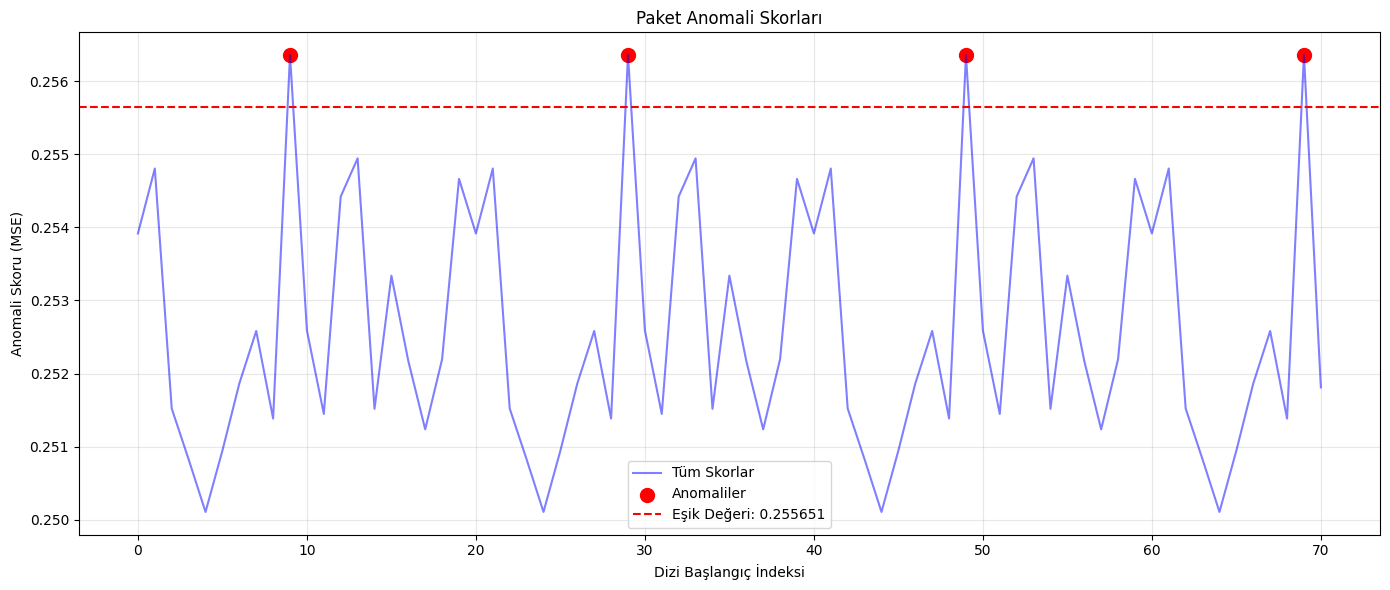

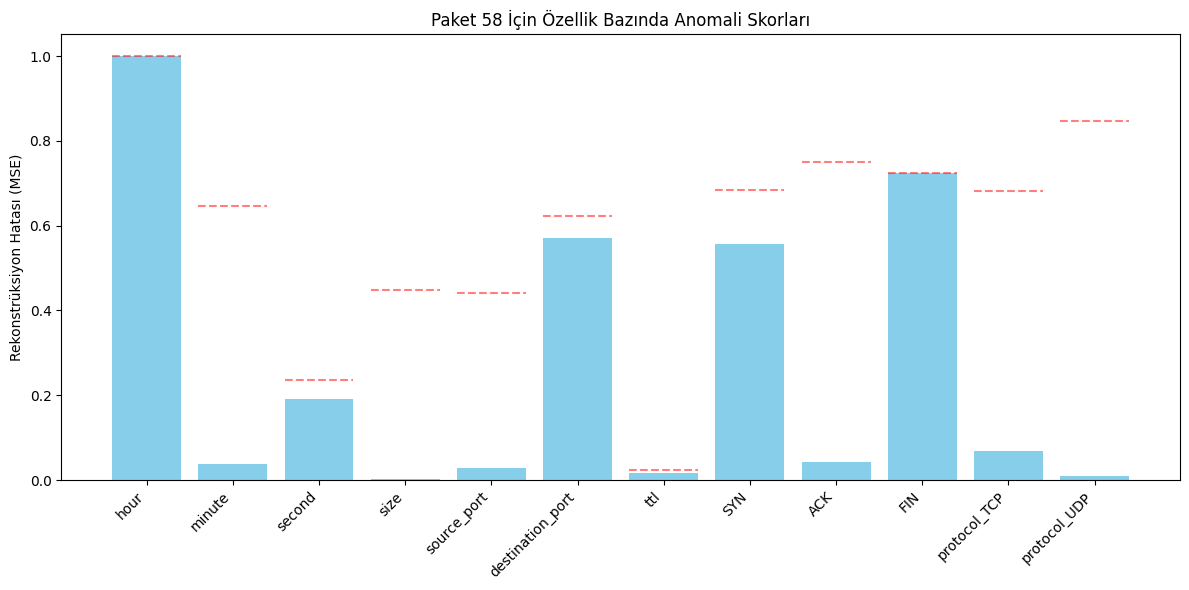

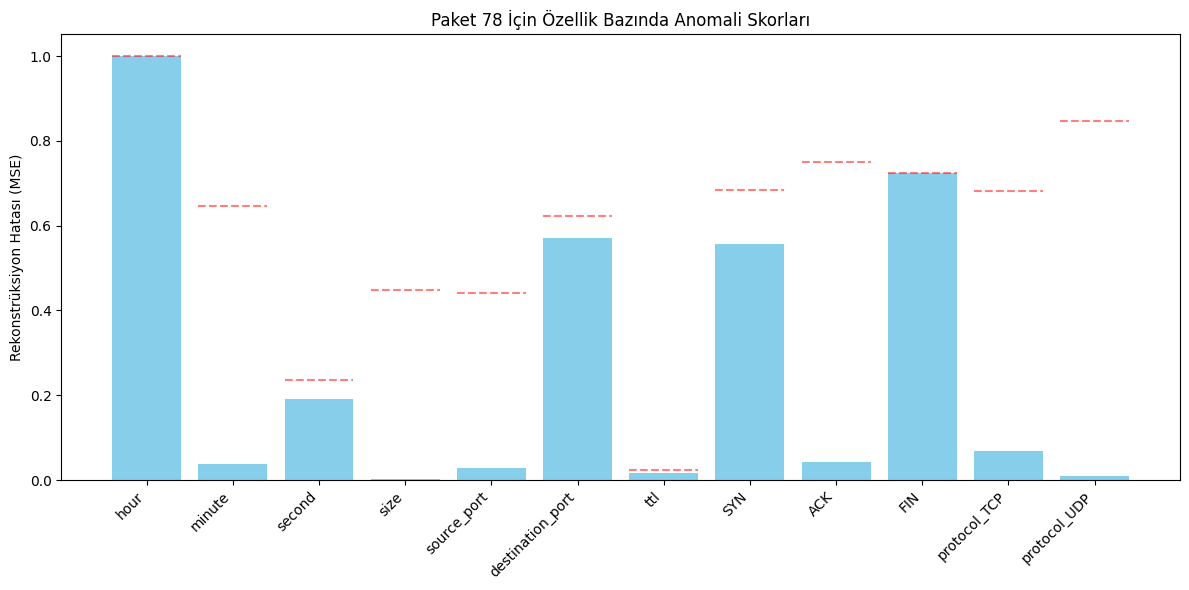

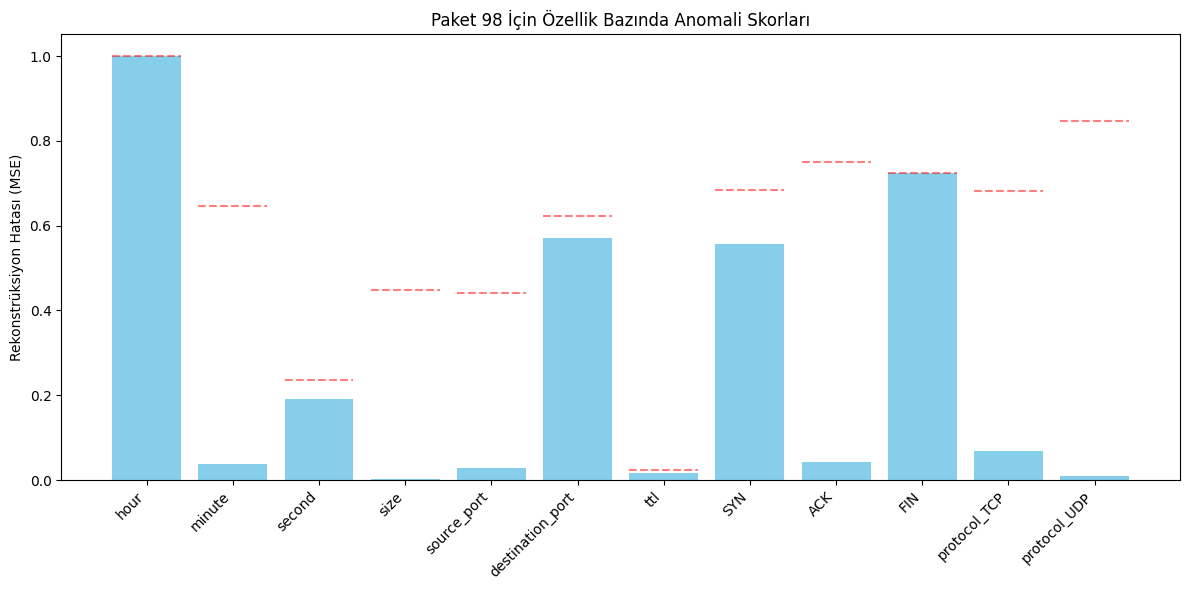

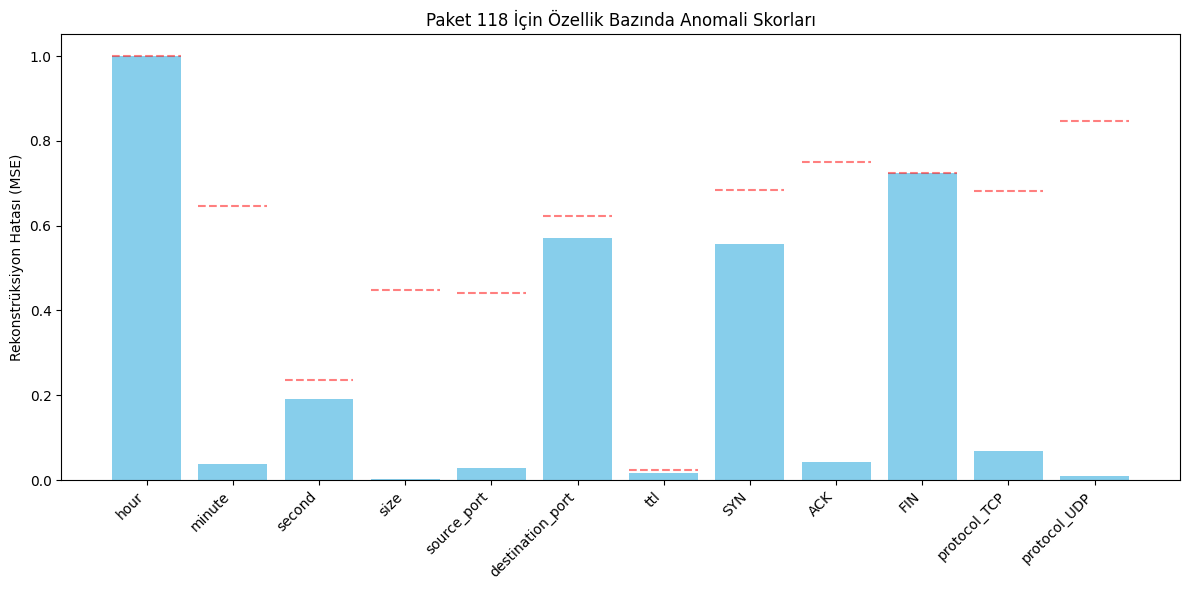

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import os
from tensorflow.keras.losses import mse as keras_mse
from tensorflow.keras.models import load_model

def load_test_data(json_file_path):
    """
    Test verilerini JSON dosyasından yükler.
    
    Args:
        json_file_path (str): Test JSON dosyasının yolu
        
    Returns:
        pandas.DataFrame: Test verisi
    """
    try:
        with open(json_file_path, 'r') as f:
            data = json.load(f)
            
        # JSON verisini pandas DataFrame'e dönüştür
        df = pd.DataFrame(data['packets'])
        print(f"Test verisi başarıyla yüklendi. {len(df)} paket bulundu.")
        return df
    except Exception as e:
        print(f"Test verisi yüklenirken hata oluştu: {str(e)}")
        return None

def preprocess_data(df, expected_columns=None):
    """
    Test verisini modele uygun şekilde ön işler.
    
    Args:
        df (pandas.DataFrame): Ham test verisi
        expected_columns (list): Model tarafından beklenen sütunlar (one-hot encoded dahil)
        
    Returns:
        pandas.DataFrame: İşlenmiş test verisi
    """
    
    try:
        # İlgili sütunları seç
        required_columns = ["hour", "minute", "second", "size", "source_port", "destination_port", "ttl", "protocol", "tcp_flags"]
        available_columns = [col for col in required_columns if col in df.columns]
        
        if not set(["hour", "minute", "second", "size"]).issubset(set(available_columns)):
            print("Uyarı: Bazı gerekli sütunlar eksik.")
        
        # Mevcut sütunları kullan
        df_processed = df[available_columns].copy()
        
        # Protokolleri one-hot encode et
        protocols_in_training = ["protocol_TCP", "protocol_UDP", "protocol_ICMP"]  # Eğitim verisindeki protokoller
        if "protocol" in df_processed.columns:
            protocol_df = pd.get_dummies(df_processed["protocol"], prefix="protocol")
            # Eğitim sırasında kullanılan tüm protokol sütunlarını ekle
            for protocol in protocols_in_training:
                if protocol not in protocol_df.columns:
                    protocol_df[protocol] = 0
            
            # Sadece eğitim sırasında kullanılan protokolleri al
            protocol_df = protocol_df[[col for col in protocols_in_training if col in protocol_df.columns]]
            
            # Ana dataframe'den protocol sütununu çıkar ve one-hot encoded sütunları ekle
            df_processed = df_processed.drop(columns=["protocol"])
            df_processed = pd.concat([df_processed, protocol_df], axis=1)
        
        # TCP bayraklarını işle
        if "tcp_flags" in df_processed.columns:
            df_processed["tcp_flags"] = df_processed["tcp_flags"].astype(str)
            df_processed["SYN"] = df_processed["tcp_flags"].apply(lambda x: int("SYN=true" in x))
            df_processed["ACK"] = df_processed["tcp_flags"].apply(lambda x: int("ACK=true" in x))
            df_processed["FIN"] = df_processed["tcp_flags"].apply(lambda x: int("FIN=true" in x))
            df_processed.drop(columns=["tcp_flags"], inplace=True)
        
        # TTL sütununu doldur
        if "ttl" in df_processed.columns and df_processed["ttl"].isna().any():
            df_processed["ttl"].fillna(df_processed["ttl"].median(), inplace=True)
        
        # NaN değerlerini doldur
        for col in df_processed.columns:
            if df_processed[col].dtype != 'object' and df_processed[col].isna().any():
                print(f"Uyarı: {col} sütununda NaN değerler var. Medyan ile dolduruluyor.")
                df_processed[col].fillna(df_processed[col].median(), inplace=True)
        
        # Modelin beklediği sütunları zorla
        if expected_columns is not None:
            for col in expected_columns:
                if col not in df_processed.columns:
                    print(f"Eksik sütun ekleniyor: {col}")
                    df_processed[col] = 0
            
            # Sadece modelin beklediği sütunları al ve aynı sırada olduklarından emin ol
            df_processed = df_processed[expected_columns]
            
        # Debug için sütunları göster
        print(f"Preprocessed data shape: {df_processed.shape}")
        print(f"Columns: {df_processed.columns.tolist()}")
                
        return df_processed
    except Exception as e:
        print(f"Veri ön işleme sırasında hata oluştu: {str(e)}")
        return None

def detect_anomalies(model_path, test_data_path, sequence_length=50, threshold=None):
    """
    Test verisindeki anomalileri tespit eder ve her anomali için hangi özelliklerin anormal olduğunu bulur.
    
    Args:
        model_path (str): Eğitilmiş model dosyasının yolu
        test_data_path (str): Test veri dosyasının yolu
        sequence_length (int): Dizilerin uzunluğu
        threshold (float): Anomali eşik değeri (None ise otomatik hesaplanır)
        
    Returns:
        list: Anomali indeksleri, skorları ve anormal özellikler
    """
    try:
        # 1. Modeli yükle
        print(f"Model yükleniyor: {model_path}")
        custom_objects = {'mse': keras_mse}
        model = load_model(model_path, custom_objects=custom_objects)
        print("Model başarıyla yüklendi.")
        
        # Model giriş boyutlarını kontrol et
        input_shape = model.input_shape
        expected_features = input_shape[2] if len(input_shape) > 2 else input_shape[1]
        print(f"Model beklenen özellik sayısı: {expected_features}")
        
        # 2. Test verisini yükle
        raw_df = load_test_data(test_data_path)
        if raw_df is None:
            return None
        
        # Beklenen sütunları tanımla - bu model için özelleştir
        # Bu bir örnek, gerçek eğitim sırasında kullanılan sütunları koymalısınız
        expected_columns = [
            "hour", "minute", "second", "size", "source_port", "destination_port", "ttl",
            "SYN", "ACK", "FIN", "protocol_TCP", "protocol_UDP"
        ]
        
        # Orijinal sütun adlarını sakla (özellik açıklamaları için)
        feature_descriptions = {
            "hour": "saat değeri",
            "minute": "dakika değeri",
            "second": "saniye değeri",
            "size": "paket boyutu",
            "source_port": "kaynak port",
            "destination_port": "hedef port",
            "ttl": "TTL değeri",
            "SYN": "SYN bayrağı",
            "ACK": "ACK bayrağı",
            "FIN": "FIN bayrağı",
            "protocol_TCP": "TCP protokolü",
            "protocol_UDP": "UDP protokolü"
        }
        
        # 3. Veriyi ön işle
        df = preprocess_data(raw_df, expected_columns=expected_columns)
        print("preprocess_data fonksiyonu başarıyla çalıştı.")
        if df is None:
            return None
            
        # 4. Veriyi normalize et
        scaler = MinMaxScaler()
        df_scaled = scaler.fit_transform(df)
        
        # Ölçeklendirme öncesi değerleri sakla (yorumlama için)
        df_original = df.copy()
        
        # Özellik sayısını kontrol et
        print(f"Ön işlenmiş veri özellikleri: {df_scaled.shape[1]}")
        if df_scaled.shape[1] != expected_features:
            print(f"HATA: Model {expected_features} özellik bekliyor, ancak veri {df_scaled.shape[1]} özelliğe sahip.")
            print("Lütfen expected_columns listesini model eğitimi sırasında kullanılan doğru sütunlarla güncelleyin.")
            return None
        
        # 5. Her paket için rekonstrüksiyon hatalarını özellik bazında hesapla
        individual_scores = []
        feature_errors = [] 
        sequences = []
        reconstructions = []
        
        for i in range(len(df_scaled)):
            # İndeks dışına çıkma durumunu kontrol et
            if i + sequence_length > len(df_scaled):
                break
                
            # Diziyi oluştur
            sequence = df_scaled[i:i+sequence_length]
            sequence = np.expand_dims(sequence, axis=0)  # Batch boyutunu ekle
            
            # Yeniden oluştur
            reconstructed = model.predict(sequence, verbose=0)
            
            # Toplam MSE hesapla
            mse = np.mean(np.power(sequence - reconstructed, 2))
            individual_scores.append((i, mse))
            
            # Son paketin orjinal ve yeniden yapılandırılmış değerlerini sakla
            sequences.append(sequence[0, -1, :])  # Son paketin orijinal değerleri
            reconstructions.append(reconstructed[0, -1, :])  # Son paketin yeniden yapılandırılmış değerleri
            
            # Özellik bazında hataları hesapla (son paket için)
            feature_mse = np.power(sequence[0, -1, :] - reconstructed[0, -1, :], 2)
            feature_errors.append(feature_mse)
        
        # 6. Eşik değeri belirle
        if threshold is None:
            mse_values = [score for _, score in individual_scores]
            threshold = np.percentile(mse_values, 95)  # 95. yüzdelik
            print(f"Otomatik belirlenen anomali eşik değeri: {threshold:.6f}")
        else:
            print(f"Belirtilen anomali eşik değeri: {threshold:.6f}")
            
        # Özellik bazında eşik değerler belirle
        feature_errors_array = np.array(feature_errors)
        feature_thresholds = np.percentile(feature_errors_array, 95, axis=0)
        
        # Normal değerlerin dağılımını hesapla (yorumlama için)
        sequences_array = np.array(sequences)
        reconstructions_array = np.array(reconstructions)
        
        # Her özellik için ortalama ve standart sapma hesapla
        feature_means = np.mean(sequences_array, axis=0)
        feature_stds = np.std(sequences_array, axis=0)
        
        # 7. Anomalileri belirle
        anomalies = []
        for i, (idx, score) in enumerate(individual_scores):
            if score > threshold:
                # Bu paketin hangi özelliklerinin anormal olduğunu belirle
                if i < len(feature_errors):
                    feature_error = feature_errors[i]
                    
                    # En anormal özellikleri bul - eşik değerini aşanlar
                    anomalous_features = []
                    for j in range(len(feature_error)):
                        if feature_error[j] > feature_thresholds[j]:
                            feature_name = expected_columns[j]
                            feature_desc = feature_descriptions.get(feature_name, feature_name)
                            
                            # Özelliğin ne kadar anormal olduğunu hesapla (z-skoru)
                            original_value = sequences_array[i, j]
                            expected_value = reconstructions_array[i, j]
                            
                            # Normalleştirilmiş değerleri orijinal ölçeğe dönüştürmek için
                            row_idx = idx + sequence_length - 1  # Dizinin son paketi
                            if row_idx < len(df_original):
                                original_raw_value = df_original.iloc[row_idx][feature_name]
                                
                                # Z-skoru hesapla
                                if feature_stds[j] > 0:
                                    z_score = (original_value - feature_means[j]) / feature_stds[j]
                                    # Anormalliğin yorumu
                                    if z_score > 0:
                                        direction = "yüksek"
                                    else:
                                        direction = "düşük"
                                    
                                    severity = abs(z_score)
                                    if severity > 3:
                                        severity_desc = "çok aykırı"
                                    elif severity > 2:
                                        severity_desc = "aykırı"
                                    else:
                                        severity_desc = "biraz aykırı"
                                    
                                    explanation = f"{feature_desc} ({original_raw_value}) {direction} ve {severity_desc}"
                                else:
                                    explanation = f"{feature_desc} ({original_raw_value}) aykırı"
                            else:
                                explanation = f"{feature_desc} aykırı"
                            
                            anomalous_features.append((feature_name, feature_error[j], explanation))
                    
                    # Anormal özellikler içerisinde en çok sapma gösterenleri sırala
                    anomalous_features.sort(key=lambda x: x[1], reverse=True)
                    
                    # Gerçek paket indeksini hesapla (dizinin son paketi)
                    true_idx = idx + sequence_length - 1
                    anomalies.append((true_idx, score, anomalous_features))
                else:
                    # Dizinin son paketi
                    true_idx = idx + sequence_length - 1
                    anomalies.append((true_idx, score, []))
                
        # 8. Anomalileri raporla
        print(f"\nToplam {len(anomalies)} anomali tespit edildi.")
        print(f"Test verisinde {len(raw_df)} paket, {len(individual_scores)} sıralı dizi var.")
        
        if anomalies:
            print("\n--- Tespit Edilen Anomaliler ---")
            for idx, score, anomalous_feats in anomalies:
                if idx < len(raw_df):  # Test et, idx sınırların dışında olabilir
                    print(f"Paket indeksi: {idx}, Anomali skoru: {score:.6f}")
                    
                    # İlgili paketin özelliklerini göster
                    packet = raw_df.iloc[idx]
                    print(f"Zaman: {packet['hour']:02d}:{packet['minute']:02d}:{packet['second']:02d}")
                    print(f"Paket boyutu: {packet['size']} bayt")
                    if 'protocol' in packet:
                        print(f"Protokol: {packet['protocol']}")
                    if 'source_ip' in packet and 'destination_ip' in packet:
                        print(f"Kaynak IP: {packet['source_ip']}, Hedef IP: {packet['destination_ip']}")
                    if 'source_port' in packet and 'destination_port' in packet:
                        print(f"Kaynak port: {packet['source_port']}, Hedef port: {packet['destination_port']}")
                    if 'tcp_flags' in packet:
                        print(f"TCP bayrakları: {packet['tcp_flags']}")
                    
                    # En anormal özellikleri göster
                    if anomalous_feats:
                        print("Anomali nedenleri:")
                        for i, (feat_name, feat_error, explanation) in enumerate(anomalous_feats[:3]):
                            print(f"  {i+1}. {explanation} (Anormallik derecesi: {feat_error:.6f})")
                    else:
                        print("Anomali nedeni belirlenemedi.")
                    
                    print("------------------------")
            
            # 9. Görselleştirme
            plt.figure(figsize=(14, 6))
            
            # Tüm skorları göster
            all_scores = [score for _, score in individual_scores]
            all_indices = list(range(len(all_scores)))
            plt.plot(all_indices, all_scores, color='blue', alpha=0.5, label='Tüm Skorlar')
            
            # Anomali skorları
            anomaly_scores = [score for _, score, _ in anomalies]
            anomaly_indices = [idx - sequence_length + 1 for idx, _, _ in anomalies]  # Dizinin başlangıç indeksini hesapla
            plt.scatter(anomaly_indices, anomaly_scores, color='red', marker='o', s=100, label='Anomaliler')
            
            # Eşik değeri
            plt.axhline(y=threshold, color='r', linestyle='--', label=f'Eşik Değeri: {threshold:.6f}')
            
            plt.title('Paket Anomali Skorları')
            plt.xlabel('Dizi Başlangıç İndeksi')
            plt.ylabel('Anomali Skoru (MSE)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig("anomali_skorlari.png")
            print("Anomali skorları grafiği 'anomali_skorlari.png' dosyasına kaydedildi.")
            
            # Her anormal paket için özellik bazında hataları görselleştir
            for anomaly_idx, (idx, score, anomalous_feats) in enumerate(anomalies[:min(5, len(anomalies))]):
                sequence_start_idx = idx - sequence_length + 1
                
                # Geçerli dizi indeksini kontrol et
                if sequence_start_idx >= 0 and sequence_start_idx < len(feature_errors):
                    plt.figure(figsize=(12, 6))
                    
                    # Tüm özelliklerin hatalarını göster
                    feature_error = feature_errors[sequence_start_idx]
                    bars = plt.bar(expected_columns, feature_error, color='skyblue')
                    
                    # Özellik eşik değerlerini göster
                    for i, threshold_val in enumerate(feature_thresholds):
                        plt.plot([i-0.4, i+0.4], [threshold_val, threshold_val], 'r--', alpha=0.5)
                    
                    # Anormal özellikleri vurgula
                    for i, col in enumerate(expected_columns):
                        if feature_error[i] > feature_thresholds[i]:
                            bars[i].set_color('red')
                    
                    plt.xticks(rotation=45, ha='right')
                    plt.title(f'Paket {idx} İçin Özellik Bazında Anomali Skorları')
                    plt.ylabel('Rekonstrüksiyon Hatası (MSE)')
                    plt.tight_layout()
                    plt.savefig(f"anomali_packet_{idx}_features.png")
                    print(f"Paket {idx} için özellik bazında anomali grafiği 'anomali_packet_{idx}_features.png' dosyasına kaydedildi.")
                    
                    # En anormal 3 özellik için detaylı görselleştirme (varsa)
                    if anomalous_feats:
                        plt.figure(figsize=(10, 6))
                        top_features = [f[0] for f in anomalous_feats[:min(3, len(anomalous_feats))]]
                        top_errors = [f[1] for f in anomalous_feats[:min(3, len(anomalous_feats))]]
                        
                        # Çubuk grafik
                        bars = plt.bar(range(len(top_features)), top_errors, color=['darkred', 'firebrick', 'indianred'][:len(top_features)])
                        
                        # Açıklama ekle
                        for i, (feat, err, expl) in enumerate(anomalous_feats[:min(3, len(anomalous_feats))]):
                            plt.text(i, err/2, expl, ha='center', va='center', color='white', fontweight='bold', wrap=True)
                        
                        plt.xticks(range(len(top_features)), top_features, rotation=45, ha='right')
                        plt.title(f'Paket {idx} İçin Başlıca Anomali Nedenleri')
                        plt.tight_layout()
                        plt.savefig(f"anomali_packet_{idx}_reasons.png")
                        print(f"Paket {idx} için anomali nedenleri grafiği 'anomali_packet_{idx}_reasons.png' dosyasına kaydedildi.")
            
        return anomalies
            
    except Exception as e:
        print(f"Anomali tespiti sırasında bir hata oluştu: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

def main():
    """
    Ana fonksiyon
    """
    print("Anomali Tespit Aracı")
    print("====================")
    
    # Model dosyasını seç
    model_path = 'C:\\Users\\PC\\Desktop\\21subat\\25_subat\\just_lstm_autoencoder.h5'
    if not os.path.exists(model_path):
        print(f"Hata: {model_path} dosyası bulunamadı.")
        return
    
    # Test verisini seç
    test_data_path ="C:\\Users\\PC\\Desktop\\21subat\\7mart\\test_verisi.json"
    if not os.path.exists(test_data_path):
        print(f"Hata: {test_data_path} dosyası bulunamadı.")
        return
    
    # Anomali tespitini gerçekleştir
    detect_anomalies(model_path, test_data_path)
    
    print("\nİşlem tamamlandı!")

if __name__ == "__main__":
    main()